In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import logit
from statsmodels.tools.tools import add_constant

In this study we will look at a health insurance market. Each customer **id** (and **income**) appears five times in this data set. Each instance shows the **premium** and **deductible** offered by one of five **insurance** company plans. For each customer, their actual plan **choice** has a value of 1 and 0 for all others.

For this study we will only look at the `Health` **insurance** company. The **choice** column thus simply indicates whether a customer chose or did not choose this plan.

In [2]:
Insurance = pd.read_csv("health_insurance.csv")
Insurance = Insurance[Insurance.insurance=="Health"]
Insurance

,id,premium,deductible,income,insurance,choice
0,1,2.867989,1.700826,5.736151,Health,1
5,2,3.517933,1.241650,2.892377,Health,0
10,3,2.301227,1.280451,4.693924,Health,1
15,4,3.500633,0.849375,8.164590,Health,0
20,5,4.069839,1.036672,5.669116,Health,1
...,...,...,...,...,...,...
1225,246,2.830426,1.121793,4.788448,Health,0
1230,247,2.815887,1.053093,7.316473,Health,0
1235,248,3.460201,1.169178,4.931877,Health,0
1240,249,3.371881,1.282090,3.367799,Health,0


We can easily estimate a logit model with covariates by calling logit() from statsmodels.

In [3]:
model = logit("choice~premium+deductible+income", Insurance).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.435722
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 choice   No. Observations:                  250
Model:                          Logit   Df Residuals:                      246
Method:                           MLE   Df Model:                            3
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1387
Time:                        14:43:24   Log-Likelihood:                -108.93
converged:                       True   LL-Null:                       -126.47
Covariance Type:            nonrobust   LLR p-value:                 1.167e-07
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9430      1.569      3.151      0.002       1.868       8.018
premium       -1.9752      0.394     -5.016      0.000      -2.747      -1.203
deductible    -0.9401      0.588     -1.598      0.110      -2.093       0.213
income         0.2265      0.124      1.823      0.068      -0.017       0.470
==============================================================================
"""

Suppose we have a customer that has **deductible** $=3$ and **income** $=6$. We can visualize how their probability of choosing this plan depends on **premium**, while all other factors are kept constant. 

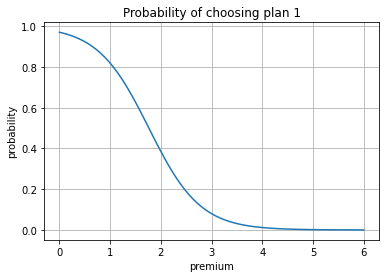

In [4]:
deductible, income = 3, 6

constant = model.params[0] + deductible*model.params[2] + income*model.params[3]
beta1 = model.params[1]
premium = np.linspace(0, 6, 100)

plt.plot(premium, np.exp(constant+beta1*premium) / (1+np.exp(constant+beta1*premium)))
plt.title("Probability of choosing plan 1")
plt.xlabel("premium")
plt.ylabel("probability")
plt.grid()
plt.show()

One metric that the `Health` insurance company is interested in is the *expected total premium* that it charges the customers in this data set. This is simply the sum of all premium values, each weighted by the probability of the customer actually enrolling in the plan.

In [5]:
X = Insurance[["premium", "deductible", "income"]]
X = add_constant(X)
params = model.params.values

p = np.exp(X @ params) / (1 + np.exp(X @ params))
expected_premium = np.sum(p*Insurance["premium"])
expected_premium

152.98781639451195

Now suppose that `Health` is switching to a flat or constant **premium** model. In other words, all customers in our data set are charged the same **premium**, while their other predictor values remain the same. 

`Health` wants to maximize their revenues from charging a higher premium for everyone. However, we also see above that the probability of a customer choosing this plan varies inversely with the premium.

Compute and plot the expected total premium for individual customer premiums ranging between 0 and 6. What value of individual premium *maximizes* the expected total premium ?

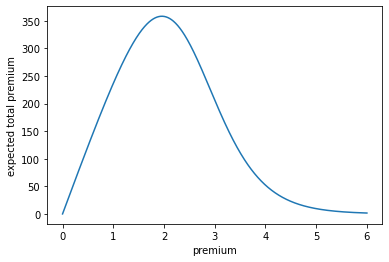

In [6]:
premiums = np.linspace(0,6,1000)
revenues = []

for premium in premiums:
    X["premium"] = premium
    p = np.exp(X @ params) / (1 + np.exp(X @ params))
    revenues.append(np.sum(p)*premium)

plt.plot(premiums, revenues)
plt.xlabel("premium")
plt.ylabel("expected total premium")
plt.show()

In [7]:
idx = revenues.index(max(revenues))
print("optimal premium: ", premiums[idx])
print("total expected premium: ", max(revenues))

optimal premium:  1.957957957957958
total expected premium:  358.06557491668855
